In [1]:
import torch
from torch.utils.data import DataLoader, Subset
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import numpy as np
import os
import sys
import pandas as pd
from sklearn.model_selection import train_test_split

In [2]:
ROOT_DIR = os.path.abspath(os.path.join(os.path.dirname(os.getcwd()), "../"))
if ROOT_DIR not in sys.path:
    sys.path.insert(0, ROOT_DIR)
print(ROOT_DIR)


from src.model.efficientNetB5_triplet import EfficientNetB5TripletClassifier

model = EfficientNetB5TripletClassifier.load_from_checkpoint(os.path.join(ROOT_DIR, "artifacts", "efficientnetb5_triplet", "efficientnetb5_triplet1_25.ckpt"))

model.eval()

/root/upstageailab-cv-classification-cv_7


/root/upstageailab-cv-classification-cv_7/src/model/efficientNetB5_triplet.py:158: UserWarning: 
The version_base parameter is not specified.
Please specify a compatability version level, or None.
Will assume defaults for version 1.1
  @hydra.main(config_path="../../configs", config_name="config")


EfficientNetB5TripletClassifier(
  (model): EfficientNet(
    (conv_stem): Conv2d(3, 48, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (bn1): BatchNormAct2d(
      48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
      (drop): Identity()
      (act): SiLU(inplace=True)
    )
    (blocks): Sequential(
      (0): Sequential(
        (0): DepthwiseSeparableConv(
          (conv_dw): Conv2d(48, 48, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=48, bias=False)
          (bn1): BatchNormAct2d(
            48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
            (drop): Identity()
            (act): SiLU(inplace=True)
          )
          (se): SqueezeExcite(
            (conv_reduce): Conv2d(48, 12, kernel_size=(1, 1), stride=(1, 1))
            (act1): SiLU(inplace=True)
            (conv_expand): Conv2d(12, 48, kernel_size=(1, 1), stride=(1, 1))
            (gate): Sigmoid()
          )
          (conv_pw): Conv2d(48

In [3]:
from src.dataset.triplet37dataset import Class3and7TripletDataset
from src.dataset.dataset import DocumentDataset
from src.transform.custom_transform_ratio import get_transform_norm_tensor, get_augraphy_transform, get_transform_rotation

data_dir = "./../../data"
df = pd.read_csv("./../../data/train.csv")

train_df, val_df = train_test_split(
                df,
                test_size=0.2,
                stratify=df.values[:, 1],
                random_state=42
            )

dataset_augraphy = DocumentDataset(val_df.values, data_dir, aug_pipeline=get_augraphy_transform(), transform=[get_transform_rotation(), get_transform_norm_tensor(image_size=(456, 456), image_normalization={"mean": [0.485, 0.456, 0.406], "std": [0.229, 0.224, 0.225]})])

dataset_no_augraphy = DocumentDataset(val_df.values, data_dir, aug_pipeline=None, transform=[get_transform_rotation(), get_transform_norm_tensor(image_size=(456, 456), image_normalization={"mean": [0.485, 0.456, 0.406], "std": [0.229, 0.224, 0.225]})])

dataset = torch.utils.data.ConcatDataset([dataset_augraphy, dataset_no_augraphy])



In [4]:
# ✅ 클래스 3, 7 데이터만 필터링
cls_3_indices = [i for i, (_, y) in enumerate(dataset) if y == 3]
cls_7_indices = [i for i, (_, y) in enumerate(dataset) if y == 7]

In [5]:
subset_indices = cls_3_indices[:100] + cls_7_indices[:100]  # 각 클래스 50개만
subset = Subset(dataset, subset_indices)
loader = DataLoader(subset, batch_size=32, shuffle=False)

In [6]:
embeddings = []
labels = []

with torch.no_grad():
    for x, y in loader:
        x = x.cuda()
        emb = model.extract_embedding(x)
        embeddings.append(emb.cpu())
        labels.append(y)

embeddings = torch.cat(embeddings).numpy()
labels = torch.cat(labels).numpy()

In [7]:
from sklearn.manifold import TSNE
tsne = TSNE(n_components=2, random_state=42)
emb_2d = tsne.fit_transform(embeddings)


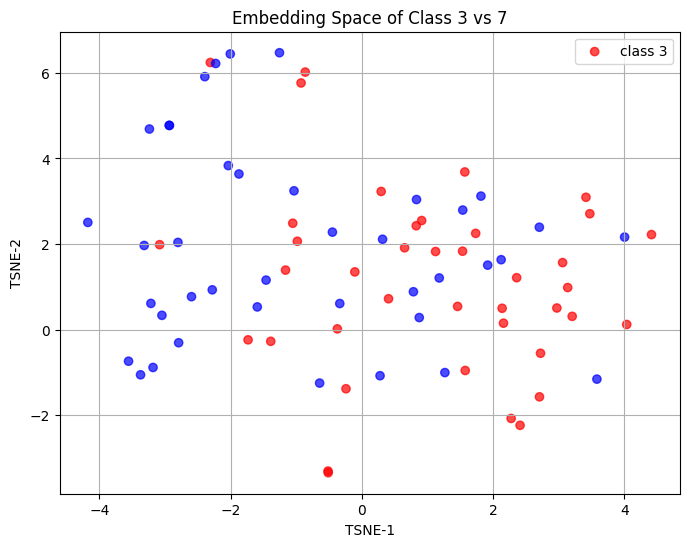

: 

In [ ]:
plt.figure(figsize=(8, 6))
colors = ['red' if l == 3 else 'blue' for l in labels]
plt.scatter(emb_2d[:, 0], emb_2d[:, 1], c=colors, label=labels, alpha=0.7)
plt.title("Embedding Space of Class 3 vs 7")
plt.xlabel("TSNE-1")
plt.ylabel("TSNE-2")
plt.legend(["class 3", "class 7"])
plt.grid(True)
plt.show()